<a href="https://colab.research.google.com/github/MHKayahan/Veri-Bilimine-Giris-2025-2026-Proje--Website-Phishing-/blob/main/src/VeriBilimineGirisProje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- MODEL DOĞRULUK ORANLARI ---
Karar Ağacı Doğruluk Tahmin Oranı: 0.8782
Rastgele Orman Doğruluk Tahmin Oranı: 0.8782
K-En Yakın Komşu Doğruluk Tahmin Oranı: 0.8561
Basit Bayes Doğruluk Tahmin Oranı: 0.8118


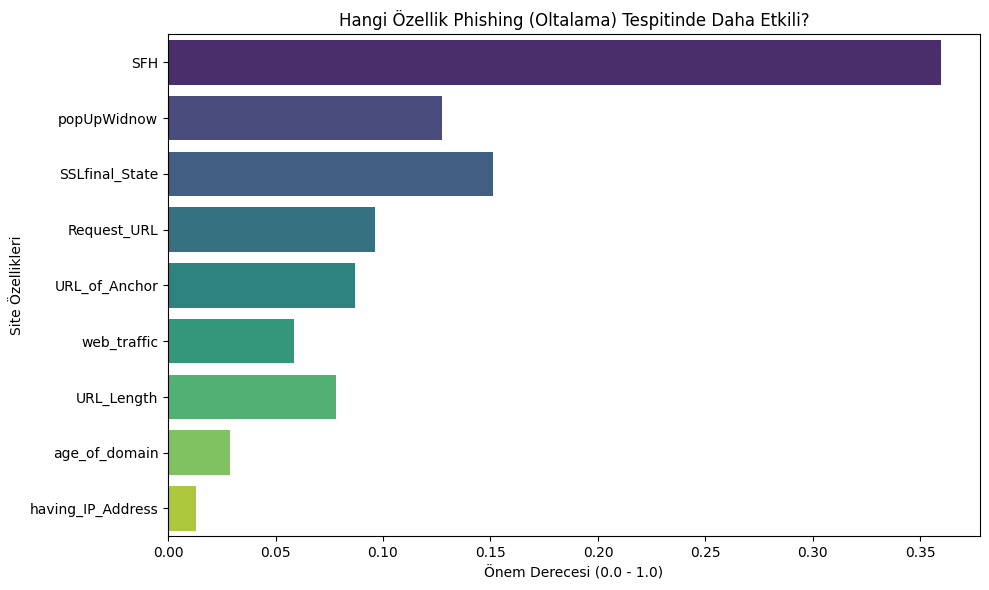


--- RASTGELE ORMAN İÇİN İNCE AYAR (GridSearchCV) ---
En iyi ayarlar aranıyor...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Bulunan En İyi Parametreler: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Optimize Edilmiş Yeni Doğruluk Oranı: 0.8782

Veri Setinin İlk 5 Satırı:
   SFH  popUpWidnow  SSLfinal_State  Request_URL  URL_of_Anchor  web_traffic  \
0    1           -1               1           -1             -1            1   
1   -1           -1              -1           -1             -1            0   
2    1           -1               0            0             -1            0   
3    1            0               1           -1             -1            0   
4   -1           -1               1           -1              0            0   

   URL_Length  age_of_domain  having_IP_Address  Result  
0           1              1                  0       0  
1           1              1                  1       1  
2          -1              1         

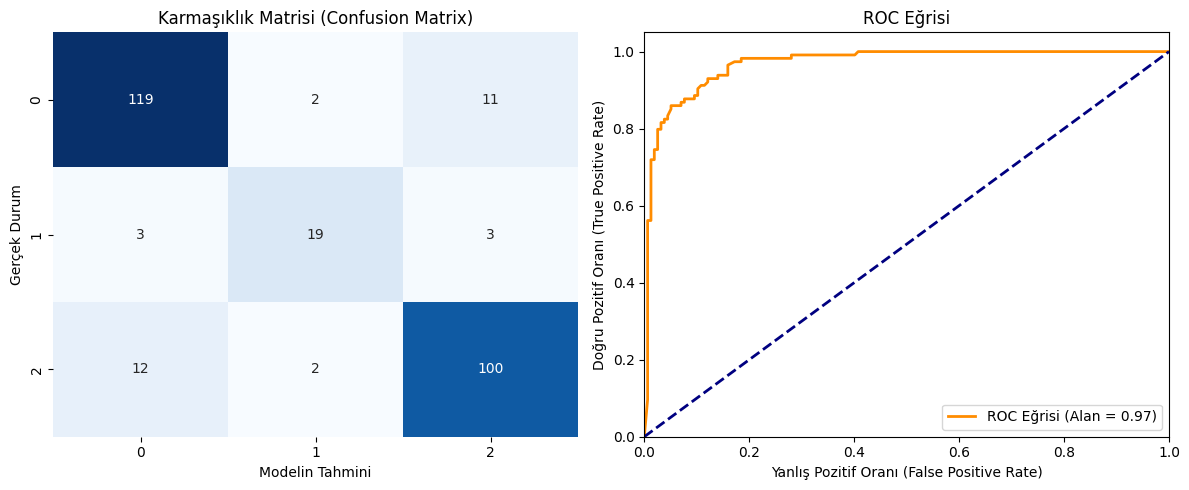

In [ ]:
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

#  ARFF Dosyasını Yükleme
data, meta = arff.loadarff('PhishingData.arff')

#  Veriyi Pandas DataFrame'ine Dönüştürme
df = pd.DataFrame(data)

#  Veri Tiplerini Düzeltme
for col in df.columns:
    if pd.api.types.is_object_dtype(df[col]):
        df[col] = df[col].str.decode('utf-8').astype(int)

#  Özellikler (X) ve Hedef Değişken (y) Ayrımı
X = df.drop('Result', axis=1)
y = df['Result']

#  Veriyi Eğitim (%80) ve Test (%20) Olarak İkiye Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -  MODELLERİ TANIMLAMA VE EĞİTME -
models = {
    "Karar Ağacı": DecisionTreeClassifier(random_state=42),
    "Rastgele Orman": RandomForestClassifier(random_state=42),
    "K-En Yakın Komşu": KNeighborsClassifier(),
    "Basit Bayes": GaussianNB()
}

print("\n- MODEL DOĞRULUK ORANLARI -")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} Doğruluk Tahmin Oranı: {accuracy:.4f}")

# -  ÖZELLİK ÖNEM DERECESİ GRAFİĞİ -
rf_model = models["Rastgele Orman"]
feature_importances = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=X.columns, palette="viridis", hue=X.columns, legend=False)
plt.title('Hangi Özellik Phishing (Oltalama) Tespitinde Daha Etkili?')
plt.xlabel('Önem Derecesi (0.0 - 1.0)')
plt.ylabel('Site Özellikleri')
plt.tight_layout()
plt.show()

# -  HİPERPARAMETRE OPTİMİZASYONU -
print("\n- RASTGELE ORMAN İÇİN İNCE AYAR (GridSearchCV) -")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=param_grid,
                       cv=5,
                       n_jobs=-1,
                       verbose=1)

print("En iyi ayarlar aranıyor..")
rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_
optimized_predictions = best_rf_model.predict(X_test)
optimized_accuracy = accuracy_score(y_test, optimized_predictions)

print(f"\nBulunan En İyi Parametreler: {rf_grid.best_params_}")
print(f"Optimize Edilmiş Yeni Doğruluk Oranı: {optimized_accuracy:.4f}")

print("\nVeri Setinin İlk 5 Satırı:")
print(df.head())

# -  SENTETİK VERİ TESTİ -
print("\n- SENTETİK VERİ TESTİ -")
sentetik_veriler = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [-1, -1, -1, -1, -1, -1, -1, -1, -1],
    [1, -1, -1, 1, 0, -1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, -1, 1, 1, 1, 1, 1, 1]
]

sentetik_df = pd.DataFrame(sentetik_veriler, columns=X.columns)
sentetik_tahminler = best_rf_model.predict(sentetik_df)

print("Sentetik Siteler İçin Modelin Tahminleri (1: Phishing, 0: Şüpheli, 2: Güvenli):")
for i, tahmin in enumerate(sentetik_tahminler):
    sonuc = "PHISHING (Tehlikeli)" if tahmin == 1 else "GÜVENLİ"
    print(f"{i+1}. Senaryo Sitesi: {sonuc}")

# -  KARMAŞIKLIK MATRİSİ VE ROC EĞRİSİ ÇİZİMİ -
plt.figure(figsize=(12, 5))

# Sol taraf: Karmaşıklık Matrisi
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, optimized_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Karmaşıklık Matrisi (Confusion Matrix)")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Durum")

# Sağ taraf: ROC Eğrisi
plt.subplot(1, 2, 2)
#  ROC eğrisi
y_prob = best_rf_model.predict_proba(X_test)[:, 2]
y_test_binary = y_test.apply(lambda x: 1 if x == 1 else 0)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (Alan = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('ROC Eğrisi')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()